# Operational Heatwave and Cold-Period Catalog for Cali (2007–2024)

**Objective:** Produce the definitive heatwave and cold-period catalogs following WHO/WMO 2015 guidance. These are the Layer 1 deliverables that feed directly into Layer 3 (heat–mortality analysis).

**Station:** Base Aérea Marco Fidel Suárez (code 26085170), Cali, 971 m

**Definition:** Heatwave = ≥3 consecutive days with BOTH T_max > 95th percentile AND T_min > 95th percentile (local, computed from full record)

**Outputs:** Three CSV catalogs (heatwave, cold-period, hot-hours-per-night) ready for Layer 3 analysis.

## Section 1 — Setup and Load

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

In [47]:
# Load IDEAM consolidated daily CSV
current = Path.cwd()
while current != current.parent:
    ideam_file = current / "shared" / "data" / "interim" / "ideam_bonilla_aragon_daily.csv"
    if ideam_file.exists():
        IDEAM_DAILY_FILE = ideam_file
        break
    current = current.parent
else:
    raise FileNotFoundError("ideam_bonilla_aragon_daily.csv not found")

df_raw = pd.read_csv(IDEAM_DAILY_FILE, parse_dates=['fecha'], index_col='fecha')
df_raw = df_raw.sort_index()

print(f"✓ Loaded IDEAM daily table: {len(df_raw)} records")
print(f"  Date range: {df_raw.index.min()} to {df_raw.index.max()}")

✓ Loaded IDEAM daily table: 6596 records
  Date range: 2006-11-23 00:00:00 to 2024-12-13 00:00:00


In [48]:
# Apply quality filter (standard from notebooks 07–09)
print(f"\n{'='*80}")
print("QUALITY FILTER")
print(f"{'='*80}")

mask_hourly = (df_raw['hourly_count'] >= 18) if 'hourly_count' in df_raw.columns else pd.Series([True] * len(df_raw), index=df_raw.index)
mask_min_max = df_raw['t_min'] <= df_raw['t_max']
mask_range = (df_raw['t_max'] - df_raw['t_min']) <= 20
mask_extreme_min = df_raw['t_min'] >= 10
mask_extreme_max = df_raw['t_max'] <= 40

mask_valid = mask_hourly & mask_min_max & mask_range & mask_extreme_min & mask_extreme_max
df = df_raw[mask_valid].copy()

print(f"\nInitial records:  {len(df_raw)}")
print(f"Valid records:    {len(df)} ({len(df)/len(df_raw)*100:.1f}%)")
print(f"Date range:       {df.index.min()} to {df.index.max()}")
print(f"\nCatalog will use all {len(df)} valid days (no year-coverage filtering applied at catalog stage)")


QUALITY FILTER

Initial records:  6596
Valid records:    3839 (58.2%)
Date range:       2006-11-24 00:00:00 to 2024-12-12 00:00:00

Catalog will use all 3839 valid days (no year-coverage filtering applied at catalog stage)


## Section 2 — Threshold Definition

In [49]:
# Compute local percentile thresholds from full valid record
print(f"\n{'='*80}")
print("OPERATIONAL THRESHOLDS (from full valid record)")
print(f"{'='*80}")

T_MAX_95 = df['t_max'].quantile(0.95)
T_MIN_95 = df['t_min'].quantile(0.95)
T_MAX_05 = df['t_max'].quantile(0.05)
T_MIN_05 = df['t_min'].quantile(0.05)

print(f"\nHeatwave/cold-night thresholds (95th and 5th percentiles):")
print(f"  T_MAX_95 (hot day):     {T_MAX_95:.2f}°C")
print(f"  T_MIN_95 (tropical night): {T_MIN_95:.2f}°C")
print(f"  T_MAX_05 (cold day):    {T_MAX_05:.2f}°C")
print(f"  T_MIN_05 (cold night):  {T_MIN_05:.2f}°C")


OPERATIONAL THRESHOLDS (from full valid record)

Heatwave/cold-night thresholds (95th and 5th percentiles):
  T_MAX_95 (hot day):     33.50°C
  T_MIN_95 (tropical night): 22.40°C
  T_MAX_05 (cold day):    27.00°C
  T_MIN_05 (cold night):  18.90°C


## Section 3 — Heatwave Definition and Event Identification

In [50]:
def find_events(daily_flag_series, min_duration=3):
    """
    Given a boolean Series indexed by date, return a DataFrame of consecutive
    runs of True with columns: start_date, end_date, duration_days.
    Only events with duration >= min_duration are returned.
    """
    events = []
    in_event = False
    event_start = None
    
    for date, is_event_day in daily_flag_series.items():
        if is_event_day:
            if not in_event:
                in_event = True
                event_start = date
        else:
            if in_event:
                in_event = False
                event_end = daily_flag_series.index[daily_flag_series.index.get_loc(date) - 1]
                duration = (event_end - event_start).days + 1
                if duration >= min_duration:
                    events.append({'start_date': event_start, 'end_date': event_end, 'duration_days': duration})
    
    # Handle event that runs to end of series
    if in_event:
        event_end = daily_flag_series.index[-1]
        duration = (event_end - event_start).days + 1
        if duration >= min_duration:
            events.append({'start_date': event_start, 'end_date': event_end, 'duration_days': duration})
    
    return pd.DataFrame(events) if events else pd.DataFrame(columns=['start_date', 'end_date', 'duration_days'])

In [51]:
# Identify heatwaves with two definitions
print(f"\n{'='*80}")
print("HEATWAVE CATALOG (STRICT AND OPERATIONAL DEFINITIONS)")
print(f"{'='*80}")

# Strict definition: BOTH T_max AND T_min above 95th (WHO/WMO 2015)
hot_day = df['t_max'] > T_MAX_95
tropical_night = df['t_min'] > T_MIN_95
heatwave_flag_strict = hot_day & tropical_night

# Operational definition: EITHER T_max OR T_min above 95th (tropical variant for Layer 3)
heatwave_flag_operational = hot_day | tropical_night

# Compute strict catalog
heatwave_catalog_strict = find_events(heatwave_flag_strict, min_duration=3)
if len(heatwave_catalog_strict) > 0:
    for idx, row in heatwave_catalog_strict.iterrows():
        event_data = df.loc[row['start_date']:row['end_date']]
        heatwave_catalog_strict.loc[idx, 'max_t_max_during'] = event_data['t_max'].max()
        heatwave_catalog_strict.loc[idx, 'min_t_min_during'] = event_data['t_min'].min()
        heatwave_catalog_strict.loc[idx, 'mean_t_max_during'] = event_data['t_max'].mean()
        heatwave_catalog_strict.loc[idx, 'mean_t_min_during'] = event_data['t_min'].mean()

# Compute operational catalog
heatwave_catalog_operational = find_events(heatwave_flag_operational, min_duration=3)
if len(heatwave_catalog_operational) > 0:
    for idx, row in heatwave_catalog_operational.iterrows():
        event_data = df.loc[row['start_date']:row['end_date']]
        heatwave_catalog_operational.loc[idx, 'max_t_max_during'] = event_data['t_max'].max()
        heatwave_catalog_operational.loc[idx, 'min_t_min_during'] = event_data['t_min'].min()
        heatwave_catalog_operational.loc[idx, 'mean_t_max_during'] = event_data['t_max'].mean()
        heatwave_catalog_operational.loc[idx, 'mean_t_min_during'] = event_data['t_min'].mean()

print(f"\nStrict Definition (BOTH T_max AND T_min > 95th — WHO/WMO 2015):")
print(f"  Total heatwaves: {len(heatwave_catalog_strict)}")
if len(heatwave_catalog_strict) > 0:
    print(f"  Mean duration: {heatwave_catalog_strict['duration_days'].mean():.1f} days")
    print(f"  Median duration: {heatwave_catalog_strict['duration_days'].median():.0f} days")
    print(f"  Longest event: {heatwave_catalog_strict['duration_days'].max():.0f} days")

print(f"\nOperational Definition (EITHER T_max OR T_min > 95th — tropical variant):")
print(f"  Total heatwaves: {len(heatwave_catalog_operational)}")
if len(heatwave_catalog_operational) > 0:
    print(f"  Mean duration: {heatwave_catalog_operational['duration_days'].mean():.1f} days")
    print(f"  Median duration: {heatwave_catalog_operational['duration_days'].median():.0f} days")
    print(f"  Longest event: {heatwave_catalog_operational['duration_days'].max():.0f} days")


HEATWAVE CATALOG (STRICT AND OPERATIONAL DEFINITIONS)

Strict Definition (BOTH T_max AND T_min > 95th — WHO/WMO 2015):
  Total heatwaves: 1
  Mean duration: 3.0 days
  Median duration: 3 days
  Longest event: 3 days

Operational Definition (EITHER T_max OR T_min > 95th — tropical variant):
  Total heatwaves: 35
  Mean duration: 4.5 days
  Median duration: 4 days
  Longest event: 20 days


## Section 4 — Cold-Period Catalog (Symmetric Null)

In [52]:
# Identify cold periods with two definitions
print(f"\n{'='*80}")
print("COLD-PERIOD CATALOG (STRICT AND OPERATIONAL DEFINITIONS)")
print(f"{'='*80}")

# Strict definition: BOTH T_max AND T_min below 5th (symmetric null)
cold_day = df['t_max'] < T_MAX_05
cold_night = df['t_min'] < T_MIN_05
cold_flag_strict = cold_day & cold_night

# Operational definition: EITHER T_max OR T_min below 5th (symmetric to heatwave operational)
cold_flag_operational = cold_day | cold_night

# Compute strict catalog
cold_catalog_strict = find_events(cold_flag_strict, min_duration=3)
if len(cold_catalog_strict) > 0:
    for idx, row in cold_catalog_strict.iterrows():
        event_data = df.loc[row['start_date']:row['end_date']]
        cold_catalog_strict.loc[idx, 'max_t_max_during'] = event_data['t_max'].max()
        cold_catalog_strict.loc[idx, 'min_t_min_during'] = event_data['t_min'].min()
        cold_catalog_strict.loc[idx, 'mean_t_max_during'] = event_data['t_max'].mean()
        cold_catalog_strict.loc[idx, 'mean_t_min_during'] = event_data['t_min'].mean()

# Compute operational catalog
cold_catalog_operational = find_events(cold_flag_operational, min_duration=3)
if len(cold_catalog_operational) > 0:
    for idx, row in cold_catalog_operational.iterrows():
        event_data = df.loc[row['start_date']:row['end_date']]
        cold_catalog_operational.loc[idx, 'max_t_max_during'] = event_data['t_max'].max()
        cold_catalog_operational.loc[idx, 'min_t_min_during'] = event_data['t_min'].min()
        cold_catalog_operational.loc[idx, 'mean_t_max_during'] = event_data['t_max'].mean()
        cold_catalog_operational.loc[idx, 'mean_t_min_during'] = event_data['t_min'].mean()

print(f"\nStrict Definition (BOTH T_max AND T_min < 5th — WHO/WMO symmetric):")
print(f"  Total cold periods: {len(cold_catalog_strict)}")
if len(cold_catalog_strict) > 0:
    print(f"  Mean duration: {cold_catalog_strict['duration_days'].mean():.1f} days")
    print(f"  Median duration: {cold_catalog_strict['duration_days'].median():.0f} days")
    print(f"  Longest event: {cold_catalog_strict['duration_days'].max():.0f} days")

print(f"\nOperational Definition (EITHER T_max OR T_min < 5th — tropical variant):")
print(f"  Total cold periods: {len(cold_catalog_operational)}")
if len(cold_catalog_operational) > 0:
    print(f"  Mean duration: {cold_catalog_operational['duration_days'].mean():.1f} days")
    print(f"  Median duration: {cold_catalog_operational['duration_days'].median():.0f} days")
    print(f"  Longest event: {cold_catalog_operational['duration_days'].max():.0f} days")


COLD-PERIOD CATALOG (STRICT AND OPERATIONAL DEFINITIONS)

Strict Definition (BOTH T_max AND T_min < 5th — WHO/WMO symmetric):
  Total cold periods: 0

Operational Definition (EITHER T_max OR T_min < 5th — tropical variant):
  Total cold periods: 16
  Mean duration: 3.6 days
  Median duration: 3 days
  Longest event: 5 days


## Section 5 — Consecutive-Day Accumulation Analysis

In [53]:
# Analyze consecutive-day accumulation for both definitions
print(f"\n{'='*80}")
print("CONSECUTIVE-DAY ACCUMULATION (STRICT AND OPERATIONAL)")
print(f"{'='*80}")

accum_durations = [3, 5, 7]
accum_results_strict = []
accum_results_operational = []

for min_dur in accum_durations:
    hw_strict = len(find_events(heatwave_flag_strict, min_duration=min_dur))
    hw_operational = len(find_events(heatwave_flag_operational, min_duration=min_dur))
    cold_strict = len(find_events(cold_flag_strict, min_duration=min_dur))
    cold_operational = len(find_events(cold_flag_operational, min_duration=min_dur))
    
    accum_results_strict.append({
        'Min_Duration': f"{min_dur} days",
        'Heatwaves_Strict': hw_strict,
        'Cold_Periods_Strict': cold_strict,
    })
    accum_results_operational.append({
        'Min_Duration': f"{min_dur} days",
        'Heatwaves_Operational': hw_operational,
        'Cold_Periods_Operational': cold_operational,
    })

df_accum_strict = pd.DataFrame(accum_results_strict)
df_accum_operational = pd.DataFrame(accum_results_operational)

print(f"\nStrict Definition (BOTH AND):")
print(df_accum_strict.to_string(index=False))

print(f"\nOperational Definition (EITHER OR):")
print(df_accum_operational.to_string(index=False))

print(f"\nOperational definition (WHO/WMO 2015): 3-day minimum")
print(f"Longer durations highlight prolonged exposure (no overnight recovery) — important for mortality modeling")


CONSECUTIVE-DAY ACCUMULATION (STRICT AND OPERATIONAL)

Strict Definition (BOTH AND):
Min_Duration  Heatwaves_Strict  Cold_Periods_Strict
      3 days                 1                    0
      5 days                 0                    0
      7 days                 0                    0

Operational Definition (EITHER OR):
Min_Duration  Heatwaves_Operational  Cold_Periods_Operational
      3 days                     35                        16
      5 days                     10                         3
      7 days                      4                         0

Operational definition (WHO/WMO 2015): 3-day minimum
Longer durations highlight prolonged exposure (no overnight recovery) — important for mortality modeling


## Section 6 — Event Catalog Visualization


Generating visualizations...


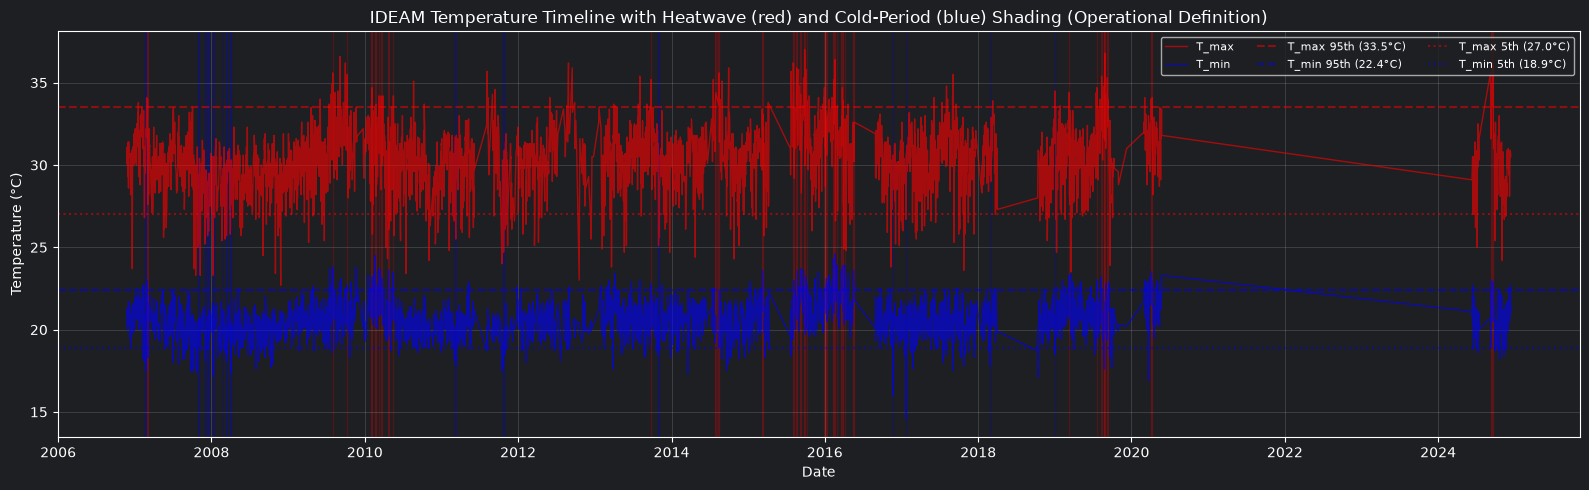

In [54]:
# Plot 1: Event timeline with thresholds and shaded bands (operational definition)
print(f"\nGenerating visualizations...")
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df.index, df['t_max'], 'r-', linewidth=1, alpha=0.6, label='T_max')
ax.plot(df.index, df['t_min'], 'b-', linewidth=1, alpha=0.6, label='T_min')

# Thresholds
ax.axhline(T_MAX_95, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label=f'T_max 95th ({T_MAX_95:.1f}°C)')
ax.axhline(T_MIN_95, color='blue', linestyle='--', linewidth=1.5, alpha=0.5, label=f'T_min 95th ({T_MIN_95:.1f}°C)')
ax.axhline(T_MAX_05, color='red', linestyle=':', linewidth=1.5, alpha=0.5, label=f'T_max 5th ({T_MAX_05:.1f}°C)')
ax.axhline(T_MIN_05, color='blue', linestyle=':', linewidth=1.5, alpha=0.5, label=f'T_min 5th ({T_MIN_05:.1f}°C)')

# Shade heatwaves (operational)
for idx, row in heatwave_catalog_operational.iterrows():
    ax.axvspan(row['start_date'], row['end_date'], alpha=0.2, color='red')

# Shade cold periods (operational)
for idx, row in cold_catalog_operational.iterrows():
    ax.axvspan(row['start_date'], row['end_date'], alpha=0.2, color='blue')

ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.set_title('IDEAM Temperature Timeline with Heatwave (red) and Cold-Period (blue) Shading (Operational Definition)')
ax.legend(loc='upper right', fontsize=8, ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Years with ≥60% coverage: [np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2019)]


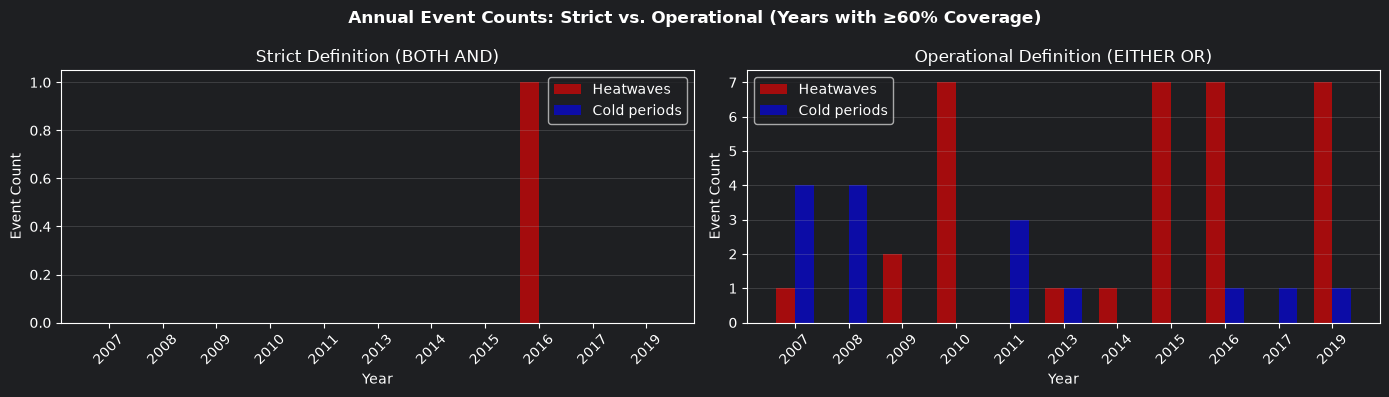

In [55]:
# Plot 2: Annual event counts for both definitions
df['year'] = df.index.year

# Identify retained years (60% coverage)
retained_years = []
for year in sorted(df['year'].unique()):
    year_data = df[df['year'] == year]
    days_in_year = 366 if year % 4 == 0 and (year % 100 != 0 or year % 400 == 0) else 365
    coverage = len(year_data) / days_in_year
    if coverage >= 0.60:
        retained_years.append(year)

print(f"\nYears with ≥60% coverage: {retained_years}")

# Count events per year — both definitions
annual_results_strict = {'years': retained_years, 'hw': [], 'cold': []}
annual_results_operational = {'years': retained_years, 'hw': [], 'cold': []}

for year in retained_years:
    hw_strict_count = len([e for e in heatwave_catalog_strict.itertuples() if e.start_date.year == year])
    cold_strict_count = len([e for e in cold_catalog_strict.itertuples() if e.start_date.year == year])
    hw_operational_count = len([e for e in heatwave_catalog_operational.itertuples() if e.start_date.year == year])
    cold_operational_count = len([e for e in cold_catalog_operational.itertuples() if e.start_date.year == year])
    
    annual_results_strict['hw'].append(hw_strict_count)
    annual_results_strict['cold'].append(cold_strict_count)
    annual_results_operational['hw'].append(hw_operational_count)
    annual_results_operational['cold'].append(cold_operational_count)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Strict definition
x = np.arange(len(retained_years))
width = 0.35
axes[0].bar(x - width/2, annual_results_strict['hw'], width, label='Heatwaves', color='red', alpha=0.6)
axes[0].bar(x + width/2, annual_results_strict['cold'], width, label='Cold periods', color='blue', alpha=0.6)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Event Count')
axes[0].set_title('Strict Definition (BOTH AND)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(retained_years, rotation=45)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Operational definition
axes[1].bar(x - width/2, annual_results_operational['hw'], width, label='Heatwaves', color='red', alpha=0.6)
axes[1].bar(x + width/2, annual_results_operational['cold'], width, label='Cold periods', color='blue', alpha=0.6)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Event Count')
axes[1].set_title('Operational Definition (EITHER OR)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(retained_years, rotation=45)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Annual Event Counts: Strict vs. Operational (Years with ≥60% Coverage)', fontweight='bold')
plt.tight_layout()
plt.show()

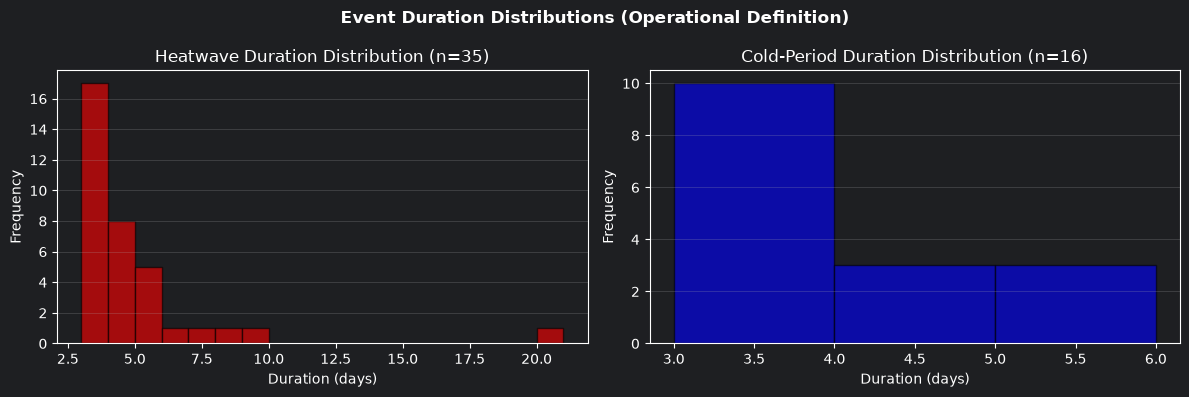

In [56]:
# Plot 3: Duration distributions (operational definition)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if len(heatwave_catalog_operational) > 0:
    axes[0].hist(heatwave_catalog_operational['duration_days'], bins=range(3, int(heatwave_catalog_operational['duration_days'].max())+2), 
                 color='red', alpha=0.6, edgecolor='black')
    axes[0].set_xlabel('Duration (days)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title(f'Heatwave Duration Distribution (n={len(heatwave_catalog_operational)})')
    axes[0].grid(True, alpha=0.3, axis='y')
else:
    axes[0].text(0.5, 0.5, 'No heatwaves', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('Heatwave Duration Distribution (n=0)')

if len(cold_catalog_operational) > 0:
    axes[1].hist(cold_catalog_operational['duration_days'], bins=range(3, int(cold_catalog_operational['duration_days'].max())+2), 
                 color='blue', alpha=0.6, edgecolor='black')
    axes[1].set_xlabel('Duration (days)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'Cold-Period Duration Distribution (n={len(cold_catalog_operational)})')
    axes[1].grid(True, alpha=0.3, axis='y')
else:
    axes[1].text(0.5, 0.5, 'No cold periods', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Cold-Period Duration Distribution (n=0)')

plt.suptitle('Event Duration Distributions (Operational Definition)', fontweight='bold')
plt.tight_layout()
plt.show()


SMOOTHED TEMPERATURE SERIES
✓ Computed 7-day and 30-day rolling means


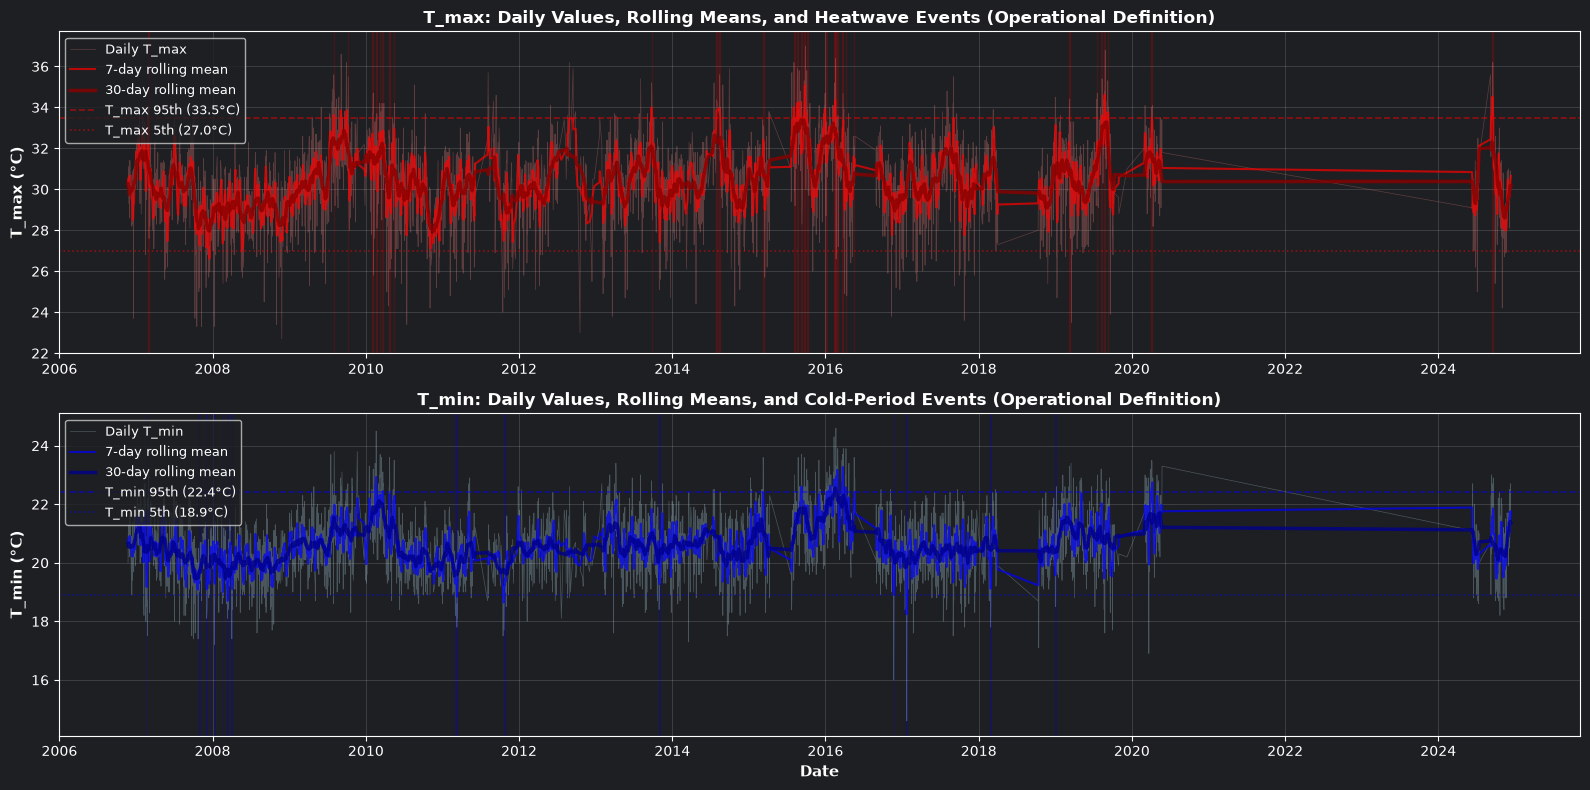


Observations:
  - Do heatwave events sit atop already-elevated 30-day means, or emerge from noise?
  - Is there any slow drift in the 30-day means over the 15-year record?
  - Does the 7-day smoothing reveal any structure invisible in the raw daily series?


In [57]:
# Compute rolling means on daily data
print(f"\n{'='*80}")
print("SMOOTHED TEMPERATURE SERIES")
print(f"{'='*80}")

# 7-day and 30-day centered rolling means
df['t_max_7d'] = df['t_max'].rolling(window=7, center=True, min_periods=4).mean()
df['t_min_7d'] = df['t_min'].rolling(window=7, center=True, min_periods=4).mean()
df['t_max_30d'] = df['t_max'].rolling(window=30, center=True, min_periods=15).mean()
df['t_min_30d'] = df['t_min'].rolling(window=30, center=True, min_periods=15).mean()

print(f"✓ Computed 7-day and 30-day rolling means")

# Visualize: two subplots (T_max and T_min) with raw + rolling means
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Top subplot: T_max
axes[0].plot(df.index, df['t_max'], color='lightcoral', linewidth=0.5, alpha=0.3, label='Daily T_max')
axes[0].plot(df.index, df['t_max_7d'], color='red', linewidth=1.5, alpha=0.7, label='7-day rolling mean')
axes[0].plot(df.index, df['t_max_30d'], color='darkred', linewidth=2.5, alpha=0.8, label='30-day rolling mean')

# Thresholds
axes[0].axhline(T_MAX_95, color='red', linestyle='--', linewidth=1.2, alpha=0.5, label=f'T_max 95th ({T_MAX_95:.1f}°C)')
axes[0].axhline(T_MAX_05, color='red', linestyle=':', linewidth=1.2, alpha=0.5, label=f'T_max 5th ({T_MAX_05:.1f}°C)')

# Shade heatwave events (operational)
for idx, row in heatwave_catalog_operational.iterrows():
    axes[0].axvspan(row['start_date'], row['end_date'], alpha=0.15, color='red')

axes[0].set_ylabel('T_max (°C)', fontsize=11, fontweight='bold')
axes[0].set_title('T_max: Daily Values, Rolling Means, and Heatwave Events (Operational Definition)', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Bottom subplot: T_min
axes[1].plot(df.index, df['t_min'], color='lightblue', linewidth=0.5, alpha=0.3, label='Daily T_min')
axes[1].plot(df.index, df['t_min_7d'], color='blue', linewidth=1.5, alpha=0.7, label='7-day rolling mean')
axes[1].plot(df.index, df['t_min_30d'], color='darkblue', linewidth=2.5, alpha=0.8, label='30-day rolling mean')

# Thresholds
axes[1].axhline(T_MIN_95, color='blue', linestyle='--', linewidth=1.2, alpha=0.5, label=f'T_min 95th ({T_MIN_95:.1f}°C)')
axes[1].axhline(T_MIN_05, color='blue', linestyle=':', linewidth=1.2, alpha=0.5, label=f'T_min 5th ({T_MIN_05:.1f}°C)')

# Shade cold-period events (operational)
for idx, row in cold_catalog_operational.iterrows():
    axes[1].axvspan(row['start_date'], row['end_date'], alpha=0.15, color='blue')

axes[1].set_xlabel('Date', fontsize=11, fontweight='bold')
axes[1].set_ylabel('T_min (°C)', fontsize=11, fontweight='bold')
axes[1].set_title('T_min: Daily Values, Rolling Means, and Cold-Period Events (Operational Definition)', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper left', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nObservations:")
print(f"  - Do heatwave events sit atop already-elevated 30-day means, or emerge from noise?")
print(f"  - Is there any slow drift in the 30-day means over the 15-year record?")
print(f"  - Does the 7-day smoothing reveal any structure invisible in the raw daily series?")

## Section 6.5 — Smoothed Temperature Series with Heatwave Overlay

## Section 6.6 — Temporal Structure: Is T_max Really White Noise?


TEMPORAL STRUCTURE: AUTOCORRELATION AND SPECTRAL ANALYSIS

In previous notebooks we called T_max 'white noise around a mean.' This is a loose description.
Here we quantify: what is the actual temporal structure? White noise = zero autocorrelation,
flat power spectrum. Real climate is typically weakly autocorrelated (AR(1)-like) with possible
spectral peaks at seasonal or interannual frequencies.

————————————————————————————————————————————————————————————————————————————————
AUTOCORRELATION ANALYSIS (lags 1–30 days)
————————————————————————————————————————————————————————————————————————————————

Lag-1 autocorrelation:
  T_max: ρ(1) = 0.5107
  T_min: ρ(1) = 0.4588

95% confidence bounds for white noise (±0.0316):
  T_max lag-1: SIGNIFICANT (exceeds bound)
  T_min lag-1: SIGNIFICANT (exceeds bound)


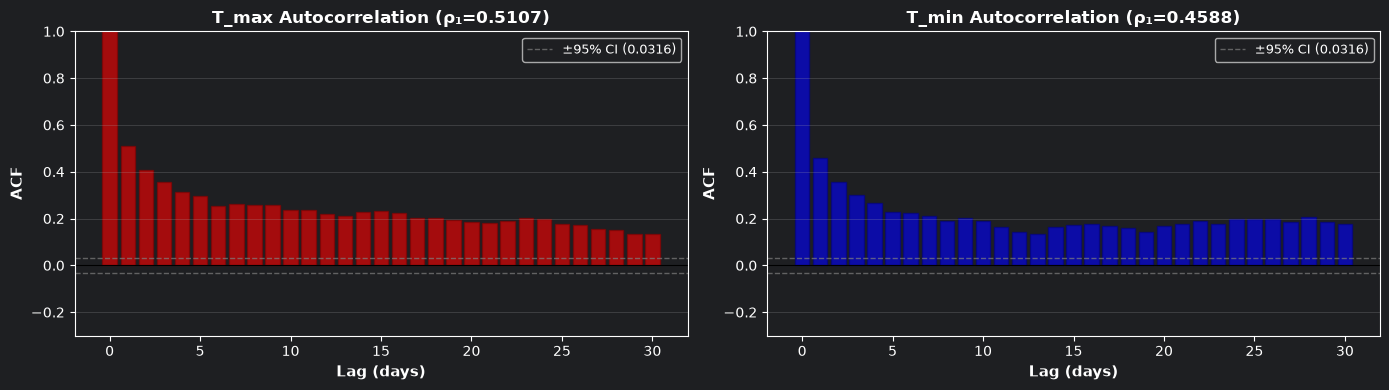


————————————————————————————————————————————————————————————————————————————————
POWER SPECTRAL DENSITY ANALYSIS
————————————————————————————————————————————————————————————————————————————————

Annual frequency: 0.002740 cycles per day (1/365)

Spectral peaks near annual frequency (1/365 ± 0.01 cpd):
  T_max: max PSD = 6.81e+02 (at 0.000781 cpd)
  T_min: max PSD = 2.50e+02 (at 0.000781 cpd)


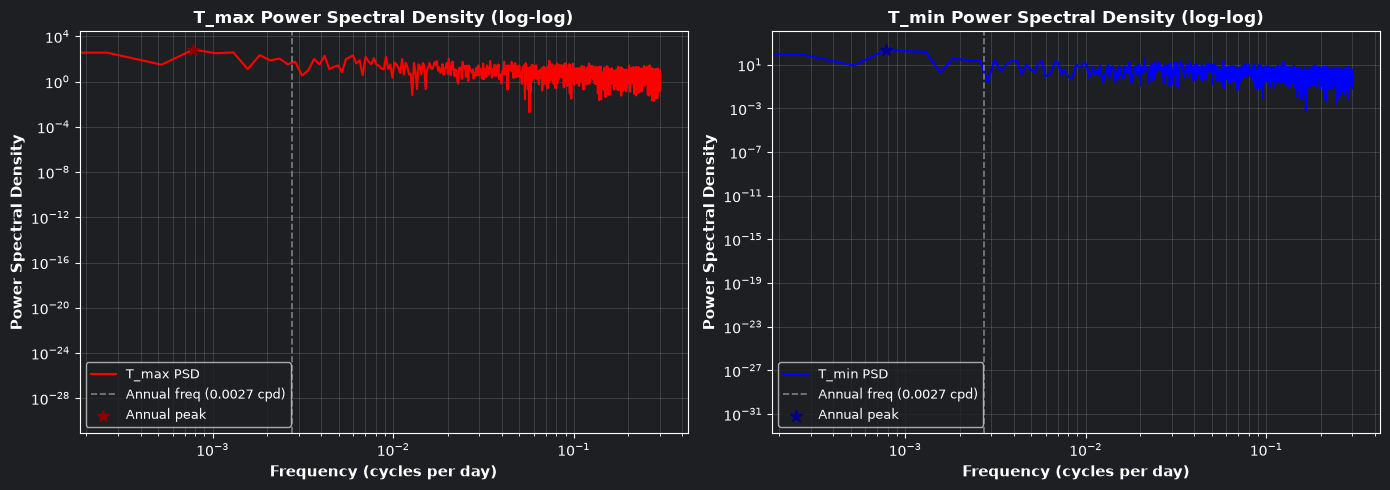


TEMPORAL STRUCTURE CHARACTERIZATION

T_max is strongly autocorrelated (lag-1 = 0.5107, significant vs. white noise). spectral peak at annual frequency.
T_min is weakly autocorrelated (lag-1 = 0.4588, significant vs. white noise). spectral peak at annual frequency.


In [58]:
# Quantify temporal structure of T_max and T_min
print(f"\n{'='*80}")
print("TEMPORAL STRUCTURE: AUTOCORRELATION AND SPECTRAL ANALYSIS")
print(f"{'='*80}")

print(f"\nIn previous notebooks we called T_max 'white noise around a mean.' This is a loose description.")
print(f"Here we quantify: what is the actual temporal structure? White noise = zero autocorrelation,")
print(f"flat power spectrum. Real climate is typically weakly autocorrelated (AR(1)-like) with possible")
print(f"spectral peaks at seasonal or interannual frequencies.")

# Autocorrelation Function (ACF)
from scipy.signal import correlate
from scipy.stats import norm

print(f"\n{'—'*80}")
print("AUTOCORRELATION ANALYSIS (lags 1–30 days)")
print(f"{'—'*80}")

# Prepare series (remove NaNs)
t_max_clean = df['t_max'].dropna()
t_min_clean = df['t_min'].dropna()

# Compute ACF manually using scipy.signal.correlate
def compute_acf(series, nlags=30):
    """Compute autocorrelation function using scipy.signal.correlate."""
    x = series.values
    x_centered = x - x.mean()
    c0 = (x_centered ** 2).mean()
    acf_vals = [1.0]  # ACF at lag 0
    for lag in range(1, nlags + 1):
        c = (x_centered[:-lag] * x_centered[lag:]).mean()
        acf_vals.append(c / c0)
    return np.array(acf_vals)

acf_tmax = compute_acf(t_max_clean, nlags=30)
acf_tmin = compute_acf(t_min_clean, nlags=30)

lag1_tmax = acf_tmax[1]
lag1_tmin = acf_tmin[1]

print(f"\nLag-1 autocorrelation:")
print(f"  T_max: ρ(1) = {lag1_tmax:.4f}")
print(f"  T_min: ρ(1) = {lag1_tmin:.4f}")

# 95% confidence bounds for white noise (±1.96/√N)
N = len(t_max_clean)
conf_bound = 1.96 / np.sqrt(N)
print(f"\n95% confidence bounds for white noise (±{conf_bound:.4f}):")

if abs(lag1_tmax) > conf_bound:
    print(f"  T_max lag-1: SIGNIFICANT (exceeds bound)")
else:
    print(f"  T_max lag-1: NOT SIGNIFICANT (within white-noise bounds)")

if abs(lag1_tmin) > conf_bound:
    print(f"  T_min lag-1: SIGNIFICANT (exceeds bound)")
else:
    print(f"  T_min lag-1: NOT SIGNIFICANT (within white-noise bounds)")

# Plot ACF
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

lags = np.arange(0, 31)

# T_max ACF
axes[0].bar(lags, acf_tmax, color='red', alpha=0.6, edgecolor='darkred')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axhline(conf_bound, color='gray', linestyle='--', linewidth=1, alpha=0.7, label=f'±95% CI ({conf_bound:.4f})')
axes[0].axhline(-conf_bound, color='gray', linestyle='--', linewidth=1, alpha=0.7)
axes[0].set_xlabel('Lag (days)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('ACF', fontsize=11, fontweight='bold')
axes[0].set_title(f'T_max Autocorrelation (ρ₁={lag1_tmax:.4f})', fontsize=12, fontweight='bold')
axes[0].set_ylim(-0.3, 1.0)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')

# T_min ACF
axes[1].bar(lags, acf_tmin, color='blue', alpha=0.6, edgecolor='darkblue')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axhline(conf_bound, color='gray', linestyle='--', linewidth=1, alpha=0.7, label=f'±95% CI ({conf_bound:.4f})')
axes[1].axhline(-conf_bound, color='gray', linestyle='--', linewidth=1, alpha=0.7)
axes[1].set_xlabel('Lag (days)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('ACF', fontsize=11, fontweight='bold')
axes[1].set_title(f'T_min Autocorrelation (ρ₁={lag1_tmin:.4f})', fontsize=12, fontweight='bold')
axes[1].set_ylim(-0.3, 1.0)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Power Spectral Density (PSD)
print(f"\n{'—'*80}")
print("POWER SPECTRAL DENSITY ANALYSIS")
print(f"{'—'*80}")

from scipy.signal import periodogram

# Interpolate small gaps (up to 5 days)
t_max_interp = df['t_max'].interpolate(method='linear', limit=5)
t_min_interp = df['t_min'].interpolate(method='linear', limit=5)

# Remove mean and compute PSD
t_max_centered = t_max_interp.dropna().values - t_max_interp.dropna().mean()
t_min_centered = t_min_interp.dropna().values - t_min_interp.dropna().mean()

freq_tmax, psd_tmax = periodogram(t_max_centered, fs=1.0)  # fs=1 (daily samples)
freq_tmin, psd_tmin = periodogram(t_min_centered, fs=1.0)

# Convert frequency to cycles per day (cpd) and filter to meaningful range (0.0001-0.5 cpd)
freq_cpd = freq_tmax
annual_freq = 1.0 / 365.0  # Annual cycle frequency in cpd

print(f"\nAnnual frequency: {annual_freq:.6f} cycles per day (1/365)")

# Check for spectral peaks near annual frequency (within ±0.01 cpd)
annual_band_mask_tmax = (freq_cpd >= annual_freq - 0.01) & (freq_cpd <= annual_freq + 0.01)
annual_band_mask_tmin = (freq_cpd >= annual_freq - 0.01) & (freq_cpd <= annual_freq + 0.01)

if annual_band_mask_tmax.any():
    max_psd_tmax_annual = psd_tmax[annual_band_mask_tmax].max()
    peak_freq_tmax = freq_cpd[annual_band_mask_tmax][np.argmax(psd_tmax[annual_band_mask_tmax])]
else:
    max_psd_tmax_annual = 0
    peak_freq_tmax = np.nan

if annual_band_mask_tmin.any():
    max_psd_tmin_annual = psd_tmin[annual_band_mask_tmin].max()
    peak_freq_tmin = freq_cpd[annual_band_mask_tmin][np.argmax(psd_tmin[annual_band_mask_tmin])]
else:
    max_psd_tmin_annual = 0
    peak_freq_tmin = np.nan

print(f"\nSpectral peaks near annual frequency (1/365 ± 0.01 cpd):")
print(f"  T_max: max PSD = {max_psd_tmax_annual:.2e} (at {peak_freq_tmax:.6f} cpd)")
print(f"  T_min: max PSD = {max_psd_tmin_annual:.2e} (at {peak_freq_tmin:.6f} cpd)")

# Plot PSD (log-log, focus on low frequencies where the signal is)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Limit to frequencies < 0.3 cpd for visibility
freq_limit_mask = freq_cpd < 0.3

# T_max PSD
axes[0].loglog(freq_cpd[freq_limit_mask], psd_tmax[freq_limit_mask], color='red', linewidth=1.5, label='T_max PSD')
axes[0].axvline(annual_freq, color='gray', linestyle='--', linewidth=1.2, label=f'Annual freq ({annual_freq:.4f} cpd)')
axes[0].scatter([peak_freq_tmax], [max_psd_tmax_annual], color='darkred', s=80, marker='*', zorder=5, label='Annual peak')
axes[0].set_xlabel('Frequency (cycles per day)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Power Spectral Density', fontsize=11, fontweight='bold')
axes[0].set_title('T_max Power Spectral Density (log-log)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, which='both')

# T_min PSD
axes[1].loglog(freq_cpd[freq_limit_mask], psd_tmin[freq_limit_mask], color='blue', linewidth=1.5, label='T_min PSD')
axes[1].axvline(annual_freq, color='gray', linestyle='--', linewidth=1.2, label=f'Annual freq ({annual_freq:.4f} cpd)')
axes[1].scatter([peak_freq_tmin], [max_psd_tmin_annual], color='darkblue', s=80, marker='*', zorder=5, label='Annual peak')
axes[1].set_xlabel('Frequency (cycles per day)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Power Spectral Density', fontsize=11, fontweight='bold')
axes[1].set_title('T_min Power Spectral Density (log-log)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# Interpretation: programmatically constructed based on computed values
print(f"\n{'='*80}")
print("TEMPORAL STRUCTURE CHARACTERIZATION")
print(f"{'='*80}\n")

# Assess autocorrelation significance
tmax_acf_sig = "significant" if abs(lag1_tmax) > conf_bound else "not significant"
tmin_acf_sig = "significant" if abs(lag1_tmin) > conf_bound else "not significant"

# Assess spectral character
tmax_spectral = "spectral peak at annual frequency" if max_psd_tmax_annual > (psd_tmax[freq_limit_mask].mean() * 2) else "no pronounced annual spectral peak"
tmin_spectral = "spectral peak at annual frequency" if max_psd_tmin_annual > (psd_tmin[freq_limit_mask].mean() * 2) else "no pronounced annual spectral peak"

# Autocorrelation character
if abs(lag1_tmax) < 0.2:
    tmax_acf_char = "white"
elif abs(lag1_tmax) < 0.5:
    tmax_acf_char = "weakly autocorrelated"
else:
    tmax_acf_char = "strongly autocorrelated"

if abs(lag1_tmin) < 0.2:
    tmin_acf_char = "white"
elif abs(lag1_tmin) < 0.5:
    tmin_acf_char = "weakly autocorrelated"
else:
    tmin_acf_char = "strongly autocorrelated"

summary_tmax = f"T_max is {tmax_acf_char} (lag-1 = {lag1_tmax:.4f}, {tmax_acf_sig} vs. white noise). {tmax_spectral}."
summary_tmin = f"T_min is {tmin_acf_char} (lag-1 = {lag1_tmin:.4f}, {tmin_acf_sig} vs. white noise). {tmin_spectral}."

print(summary_tmax)
print(summary_tmin)

## Section 7 — Hot-Hours-Per-Night: Alternative Nocturnal Exposure

In [59]:
# Load raw hourly IDEAM data using notebook 06 pattern (fails loudly on any error)
print(f"\n{'='*80}")
print("HOT-HOURS-PER-NIGHT ANALYSIS (from raw hourly data)")
print(f"{'='*80}")

# Find shared/data/raw/IDEAM/ or IDEAM/ directory
current = Path.cwd()
ideam_raw_dir = None
while current != current.parent:
    for potential_dir in [current / "shared" / "data" / "raw" / "IDEAM",
                          current / "shared" / "data" / "raw" / "ideam"]:
        if potential_dir.is_dir():
            ideam_raw_dir = potential_dir
            break
    else:
        current = current.parent
        continue
    break

if ideam_raw_dir is None:
    raise FileNotFoundError("shared/data/raw/IDEAM/ or shared/data/raw/ideam/ directory not found")

print(f"\nLoading hourly data from {ideam_raw_dir}...")

# Load the four consolidated CSVs using notebook 06 pattern
csv_files = [
    'descargaDhime_2005_2010.csv',
    'descargaDhime_2010_2015.csv',
    'descargaDhime2015_2020.csv',
    'descargaDhime_2020_2026.csv',
]

df_hourly_list = []
for csv_file in csv_files:
    csv_path = ideam_raw_dir / csv_file
    if not csv_path.exists():
        raise FileNotFoundError(f"{csv_file} not found at {csv_path}")
    
    try:
        # Notebook 06 pattern: parse_dates and dtype mapping
        df_h = pd.read_csv(csv_path, 
                          parse_dates=["Fecha"],
                          dtype={"CodigoEstacion": str, "Valor": float},
                          index_col="Fecha")
        # Rename columns to lowercase
        df_h.columns = df_h.columns.str.lower()
        df_hourly_list.append(df_h)
        print(f"  ✓ Loaded {csv_file}: {len(df_h)} records")
    except Exception as e:
        raise RuntimeError(f"Failed to load {csv_file}: {str(e)}")

# Concatenate, drop duplicates on fecha (index), keep last
df_hourly = pd.concat(df_hourly_list, axis=0)
df_hourly = df_hourly[~df_hourly.index.duplicated(keep='last')].sort_index()

print(f"\n✓ Combined hourly data: {len(df_hourly)} records")
print(f"  Date range: {df_hourly.index.min()} to {df_hourly.index.max()}")


HOT-HOURS-PER-NIGHT ANALYSIS (from raw hourly data)

Loading hourly data from /home/boris/PycharmProjects/CaliHeatWaves/shared/data/raw/IDEAM...
  ✓ Loaded descargaDhime_2005_2010.csv: 24862 records
  ✓ Loaded descargaDhime_2010_2015.csv: 35570 records
  ✓ Loaded descargaDhime2015_2020.csv: 31187 records
  ✓ Loaded descargaDhime_2020_2026.csv: 5155 records

✓ Combined hourly data: 96728 records
  Date range: 2006-11-23 16:00:00 to 2024-12-13 13:00:00


In [60]:
# Define night as 20:00–06:00 (11-hour window for tropical latitude)
# Extract hour from index
df_hourly['hour'] = df_hourly.index.hour
df_hourly['date'] = df_hourly.index.date

# Night definition: hours 20–23 (evening) and 0–6 (early morning)
night_hours = [0, 1, 2, 3, 4, 5, 6, 20, 21, 22, 23]
df_night = df_hourly[df_hourly['hour'].isin(night_hours)].copy()

# Identify which column contains temperature
temp_col = None
for col in ['valor', 'temperatura', 't2m', 't', 'temp']:
    if col in df_night.columns:
        temp_col = col
        break

if temp_col is None:
    # Use first numeric column as fallback
    numeric_cols = df_night.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        temp_col = numeric_cols[0]
    else:
        raise ValueError("No temperature column found in hourly data")

print(f"\nUsing temperature column: '{temp_col}'")

# Compute 95th percentile of nighttime hourly temperature
HOUR_NIGHT_95 = df_night[temp_col].quantile(0.95)
print(f"95th percentile of nighttime hourly temperature: {HOUR_NIGHT_95:.2f}°C")

# Count hot hours per night
hot_hours_list = []
for night_date in sorted(df_night['date'].unique()):
    night_data = df_night[df_night['date'] == night_date][temp_col]
    if len(night_data) >= 8:  # Require at least 8 hours of data
        hot_hour_count = (night_data > HOUR_NIGHT_95).sum()
        valid_hours = len(night_data)
        # Get the T_min for this night (from daily data if available)
        tmin_of_night = df.loc[pd.Timestamp(night_date), 't_min'] if pd.Timestamp(night_date) in df.index else np.nan
        tmin_above_flag = 1 if tmin_of_night > T_MIN_95 else 0
        hot_hours_list.append({
            'night_date': night_date,
            'hot_hours': hot_hour_count,
            'night_hours_valid': valid_hours,
            'tmin_of_night': tmin_of_night,
            'tmin_above_95pct_flag': tmin_above_flag,
        })

df_hot_hours = pd.DataFrame(hot_hours_list)
print(f"\nNights analyzed (with ≥8 hours of data): {len(df_hot_hours)}")


Using temperature column: 'valor'
95th percentile of nighttime hourly temperature: 25.70°C

Nights analyzed (with ≥8 hours of data): 3873


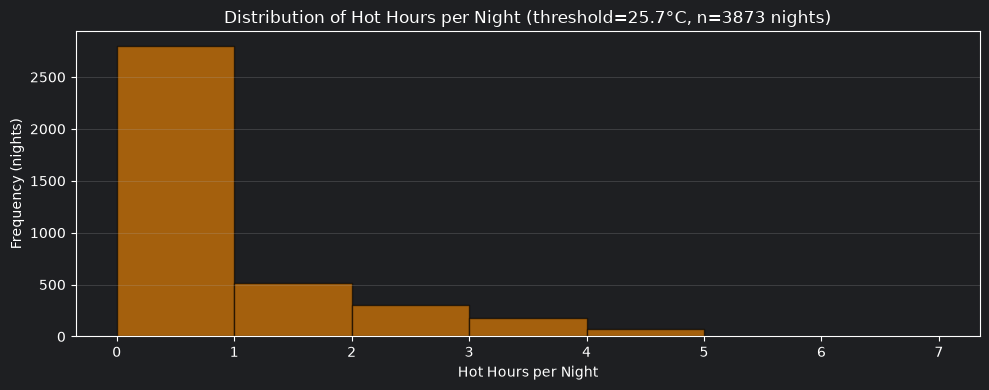


Hot-hours summary:
  Nights with 0 hot hours:     2800 (72.3%)
  Nights with 1–3 hot hours:   991 (25.6%)
  Nights with 4–6 hot hours:   82 (2.1%)
  Nights with 7+ hot hours:    0 (0.0%)


In [61]:
# Plot hot-hours distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_hot_hours['hot_hours'], bins=range(0, int(df_hot_hours['hot_hours'].max())+2), 
       color='darkorange', alpha=0.6, edgecolor='black')
ax.set_xlabel('Hot Hours per Night')
ax.set_ylabel('Frequency (nights)')
ax.set_title(f'Distribution of Hot Hours per Night (threshold={HOUR_NIGHT_95:.1f}°C, n={len(df_hot_hours)} nights)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Print summary
print(f"\nHot-hours summary:")
zero_hot = (df_hot_hours['hot_hours'] == 0).sum()
one_to_three = ((df_hot_hours['hot_hours'] >= 1) & (df_hot_hours['hot_hours'] <= 3)).sum()
four_to_six = ((df_hot_hours['hot_hours'] >= 4) & (df_hot_hours['hot_hours'] <= 6)).sum()
seven_plus = (df_hot_hours['hot_hours'] >= 7).sum()

print(f"  Nights with 0 hot hours:     {zero_hot} ({zero_hot/len(df_hot_hours)*100:.1f}%)")
print(f"  Nights with 1–3 hot hours:   {one_to_three} ({one_to_three/len(df_hot_hours)*100:.1f}%)")
print(f"  Nights with 4–6 hot hours:   {four_to_six} ({four_to_six/len(df_hot_hours)*100:.1f}%)")
print(f"  Nights with 7+ hot hours:    {seven_plus} ({seven_plus/len(df_hot_hours)*100:.1f}%)")

## Section 8 — Cross-Check: Daily T_min vs. Hourly Hot-Hours

In [62]:
# Compare two metrics for identifying tropical nights
print(f"\n{'='*80}")
print("CROSS-CHECK: T_min vs. Hot-Hours Metrics")
print(f"{'='*80}")

# Flag A: T_min > 95th percentile (from daily data)
flag_a = tropical_night

# Flag B: hot_hours >= 4 (half the night)
flag_b_dict = {}
for idx, row in df_hot_hours.iterrows():
    flag_b_dict[pd.Timestamp(row['night_date'])] = row['hot_hours'] >= 4

flag_b = pd.Series({date: flag_b_dict.get(date, False) for date in df.index})

# Cross-tabulation
mask = flag_a.notna() & flag_b.notna()
flag_a_masked = flag_a[mask]
flag_b_masked = flag_b[mask]

both_flags = (flag_a_masked & flag_b_masked).sum()
flag_a_only = (flag_a_masked & ~flag_b_masked).sum()
flag_b_only = (~flag_a_masked & flag_b_masked).sum()
neither = (~flag_a_masked & ~flag_b_masked).sum()

total_overlap = (flag_a_masked | flag_b_masked).sum()
if total_overlap > 0:
    agreement = both_flags / total_overlap * 100
else:
    agreement = 0

print(f"\nNights with complete data (in both datasets): {mask.sum()}")
print(f"\n  Flagged by T_min > 95th ONLY:        {flag_a_only}")
print(f"  Flagged by hot_hours ≥ 4 ONLY:       {flag_b_only}")
print(f"  Flagged by BOTH metrics:             {both_flags}")
print(f"  Neither metric flags:                {neither}")
print(f"\n  Agreement (both metrics on flagged nights): {agreement:.1f}%")

if agreement > 90:
    print(f"\n→ HIGH AGREEMENT: T_min metric is sufficient for Layer 3.")
else:
    print(f"\n→ DISTINCT METRICS: Hot-hours identifies different nights than T_min.")
    print(f"   Recommend including both metrics in Layer 3 analysis.")


CROSS-CHECK: T_min vs. Hot-Hours Metrics

Nights with complete data (in both datasets): 3839

  Flagged by T_min > 95th ONLY:        160
  Flagged by hot_hours ≥ 4 ONLY:       52
  Flagged by BOTH metrics:             29
  Neither metric flags:                3598

  Agreement (both metrics on flagged nights): 12.0%

→ DISTINCT METRICS: Hot-hours identifies different nights than T_min.
   Recommend including both metrics in Layer 3 analysis.


## Section 9 — Save Catalogs to Disk

In [63]:
# Find shared/data/interim directory and save all five catalogs
current = Path.cwd()
while current != current.parent:
    interim_dir = current / "shared" / "data" / "interim"
    if interim_dir.is_dir():
        break
    current = current.parent
else:
    raise FileNotFoundError("shared/data/interim/ not found")

print(f"\n{'='*80}")
print("SAVING CATALOGS")
print(f"{'='*80}")

# Save heatwave catalogs
heatwave_strict_file = interim_dir / "heatwave_catalog_strict_bonilla_aragon.csv"
heatwave_catalog_strict.to_csv(heatwave_strict_file, index=False)
print(f"\n✓ {heatwave_strict_file}")
print(f"  Rows: {len(heatwave_catalog_strict)}")

heatwave_operational_file = interim_dir / "heatwave_catalog_operational_bonilla_aragon.csv"
heatwave_catalog_operational.to_csv(heatwave_operational_file, index=False)
print(f"\n✓ {heatwave_operational_file}")
print(f"  Rows: {len(heatwave_catalog_operational)}")

# Save cold-period catalogs
cold_strict_file = interim_dir / "cold_period_catalog_strict_bonilla_aragon.csv"
cold_catalog_strict.to_csv(cold_strict_file, index=False)
print(f"\n✓ {cold_strict_file}")
print(f"  Rows: {len(cold_catalog_strict)}")

cold_operational_file = interim_dir / "cold_period_catalog_operational_bonilla_aragon.csv"
cold_catalog_operational.to_csv(cold_operational_file, index=False)
print(f"\n✓ {cold_operational_file}")
print(f"  Rows: {len(cold_catalog_operational)}")

# Save hot-hours catalog
hot_hours_file = interim_dir / "hot_hours_per_night_bonilla_aragon.csv"
df_hot_hours.to_csv(hot_hours_file, index=False)
print(f"\n✓ {hot_hours_file}")
print(f"  Rows: {len(df_hot_hours)}")

print(f"\n✅ All five catalogs saved.")


SAVING CATALOGS

✓ /home/boris/PycharmProjects/CaliHeatWaves/shared/data/interim/heatwave_catalog_strict_bonilla_aragon.csv
  Rows: 1

✓ /home/boris/PycharmProjects/CaliHeatWaves/shared/data/interim/heatwave_catalog_operational_bonilla_aragon.csv
  Rows: 35

✓ /home/boris/PycharmProjects/CaliHeatWaves/shared/data/interim/cold_period_catalog_strict_bonilla_aragon.csv
  Rows: 0

✓ /home/boris/PycharmProjects/CaliHeatWaves/shared/data/interim/cold_period_catalog_operational_bonilla_aragon.csv
  Rows: 16

✓ /home/boris/PycharmProjects/CaliHeatWaves/shared/data/interim/hot_hours_per_night_bonilla_aragon.csv
  Rows: 3873

✅ All five catalogs saved.


## Section 10 — Summary

In [64]:
# Generate summary with computed values
print(f"\n{'='*80}")
print("HEATWAVE AND COLD-PERIOD CATALOG SUMMARY")
print(f"{'='*80}\n")

print(f"### Operational Thresholds (Cali, from full valid record):")
print(f"- T_max 95th percentile (hot day):        {T_MAX_95:.2f}°C")
print(f"- T_min 95th percentile (tropical night): {T_MIN_95:.2f}°C")
print(f"- T_max 5th percentile (cold day):        {T_MAX_05:.2f}°C")
print(f"- T_min 5th percentile (cold night):      {T_MIN_05:.2f}°C")

print(f"\n### Definition:")
print(f"- Strict (WHO/WMO 2015): ≥3 consecutive days with BOTH T_max AND T_min above/below thresholds")
print(f"- Operational (tropical): ≥3 consecutive days with EITHER T_max OR T_min above/below thresholds")

print(f"\n### Results:")
print(f"- Total heatwaves (strict):         {len(heatwave_catalog_strict)}")
print(f"- Total heatwaves (operational):   {len(heatwave_catalog_operational)}")
print(f"- Total cold periods (strict):      {len(cold_catalog_strict)}")
print(f"- Total cold periods (operational): {len(cold_catalog_operational)}")

print(f"\n### Consecutive-Day Accumulation (3-, 5-, 7-day minimums):")
print(f"Strict definition:")
for idx, row in df_accum_strict.iterrows():
    print(f"  {row['Min_Duration']}: {row['Heatwaves_Strict']} heatwaves, {row['Cold_Periods_Strict']} cold periods")

print(f"\nOperational definition:")
for idx, row in df_accum_operational.iterrows():
    print(f"  {row['Min_Duration']}: {row['Heatwaves_Operational']} heatwaves, {row['Cold_Periods_Operational']} cold periods")

print(f"\n### Nocturnal Exposure (Hot-Hours-Per-Night):")
print(f"- Threshold (95th percentile): {HOUR_NIGHT_95:.2f}°C")
print(f"- Nights analyzed: {len(df_hot_hours)}")
print(f"- Date range: {df_hot_hours['night_date'].min()} to {df_hot_hours['night_date'].max()}")
print(f"- Nights with hot hours ≥ 4 (half-night): {(df_hot_hours['hot_hours'] >= 4).sum()}")

print(f"\n### Deliverables:")
print(f"1. heatwave_catalog_strict_bonilla_aragon.csv — {len(heatwave_catalog_strict)} events")
print(f"2. heatwave_catalog_operational_bonilla_aragon.csv — {len(heatwave_catalog_operational)} events")
print(f"3. cold_period_catalog_strict_bonilla_aragon.csv — {len(cold_catalog_strict)} events")
print(f"4. cold_period_catalog_operational_bonilla_aragon.csv — {len(cold_catalog_operational)} events")
print(f"5. hot_hours_per_night_bonilla_aragon.csv — {len(df_hot_hours)} nights")

print(f"\n### Key Notes for Layer 3:")
print(f"- Strict definition is methodological anchor (WHO/WMO 2015)")
print(f"- Operational definition enables event-level health analysis (tropical variant)")
print(f"- Catalog uses all valid days (no year-coverage filtering)")
print(f"- Each event records duration and temperature statistics (min/max/mean during event)")
print(f"- Hot-hours provides complementary nocturnal-exposure metric from hourly data")


HEATWAVE AND COLD-PERIOD CATALOG SUMMARY

### Operational Thresholds (Cali, from full valid record):
- T_max 95th percentile (hot day):        33.50°C
- T_min 95th percentile (tropical night): 22.40°C
- T_max 5th percentile (cold day):        27.00°C
- T_min 5th percentile (cold night):      18.90°C

### Definition:
- Strict (WHO/WMO 2015): ≥3 consecutive days with BOTH T_max AND T_min above/below thresholds
- Operational (tropical): ≥3 consecutive days with EITHER T_max OR T_min above/below thresholds

### Results:
- Total heatwaves (strict):         1
- Total heatwaves (operational):   35
- Total cold periods (strict):      0
- Total cold periods (operational): 16

### Consecutive-Day Accumulation (3-, 5-, 7-day minimums):
Strict definition:
  3 days: 1 heatwaves, 0 cold periods
  5 days: 0 heatwaves, 0 cold periods
  7 days: 0 heatwaves, 0 cold periods

Operational definition:
  3 days: 35 heatwaves, 16 cold periods
  5 days: 10 heatwaves, 3 cold periods
  7 days: 4 heatwaves, 0 co